Saving image.jpg to image (1).jpg


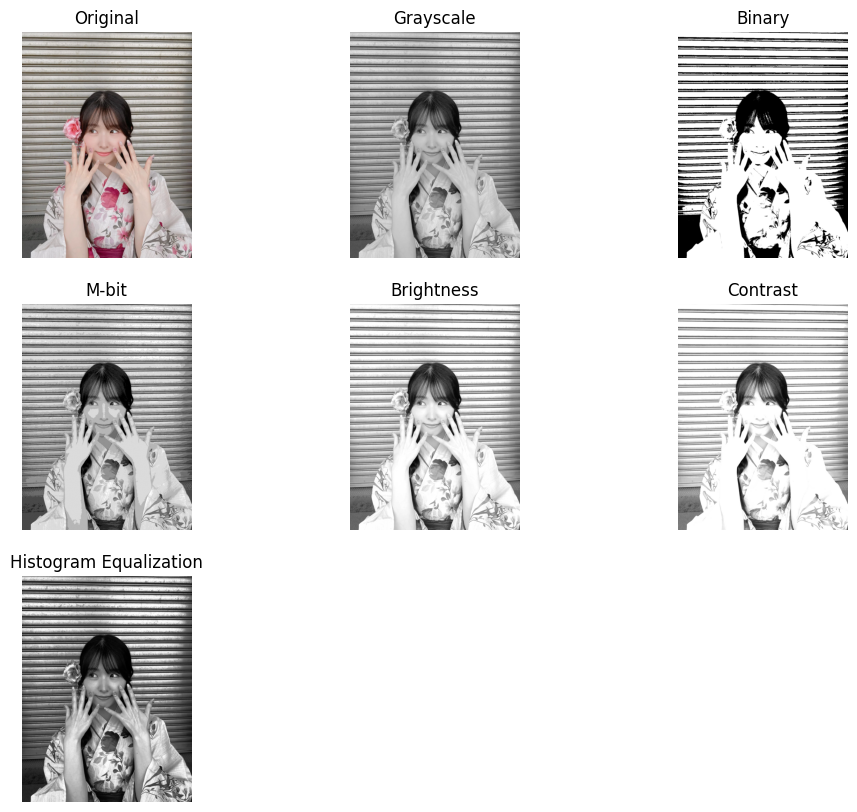

/tmp/ipykernel_1719/2857586233.py:104: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(gray.ravel(), 256, [0,256])


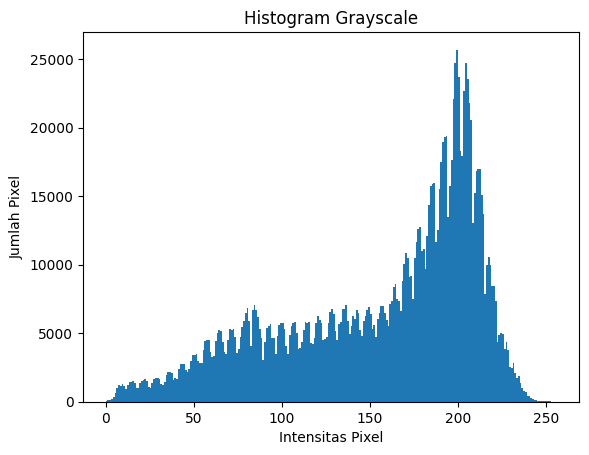

In [5]:
# ==============================
# IMPORT LIBRARY
# ==============================
import cv2                  # Library utama untuk pengolahan citra
import numpy as np          # Untuk operasi matriks/array
from matplotlib import pyplot as plt  # Untuk menampilkan gambar & histogram
from google.colab import files        # Untuk upload file di Google Colab

# ==============================
# UPLOAD FILE
# ==============================
uploaded = files.upload()   # Upload gambar dari komputer

# Ambil nama file pertama yang diupload
filename = list(uploaded.keys())[0]

# ==============================
# FUNCTION PROCESSING
# ==============================

# Fungsi konversi RGB ke grayscale
def rgb_to_gray(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Fungsi konversi grayscale ke biner (thresholding)
def gray_to_binary(gray, threshold=128):
    _, binary = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    return binary

# Fungsi konversi grayscale ke m-bit (quantization)
def gray_to_mbit(gray, levels=8):
    return (gray / 256 * levels).astype(np.uint8)

# Fungsi untuk menambah brightness (kecerahan)
def adjust_brightness(gray, beta=50):
    return cv2.convertScaleAbs(gray, alpha=1, beta=beta)

# Fungsi untuk mengatur contrast (kontras)
def adjust_contrast(gray, alpha=1.5):
    return cv2.convertScaleAbs(gray, alpha=alpha, beta=0)

# Fungsi histogram equalization (peningkatan kontras otomatis)
def histogram_equalization(gray):
    return cv2.equalizeHist(gray)

# ==============================
# MAIN PROGRAM
# ==============================

# Membaca gambar dari file
img = cv2.imread(filename)

# Konversi ke RGB (karena OpenCV default BGR)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Proses pengolahan citra
gray = rgb_to_gray(img)             # Konversi ke grayscale
binary = gray_to_binary(gray)       # Konversi ke biner
mbit = gray_to_mbit(gray)           # Konversi ke m-bit
bright = adjust_brightness(gray)    # Penambahan brightness
contrast = adjust_contrast(gray)    # Penyesuaian kontras
equalized = histogram_equalization(gray)  # Histogram equalization

# ==============================
# VISUALISASI
# ==============================

# Judul tiap gambar
titles = [
    'Original', 'Grayscale', 'Binary',
    'M-bit', 'Brightness', 'Contrast',
    'Histogram Equalization'
]

# Daftar gambar hasil proses
images = [
    img_rgb, gray, binary,
    mbit, bright, contrast,
    equalized
]

# Membuat tampilan grid
plt.figure(figsize=(12,10))

for i in range(len(images)):
    plt.subplot(3,3,i+1)

    # Gambar pertama pakai RGB, lainnya grayscale
    if i == 0:
        plt.imshow(images[i])
    else:
        plt.imshow(images[i], cmap='gray')

    plt.title(titles[i])
    plt.axis('off')

plt.show()

# ==============================
# HISTOGRAM
# ==============================

# Menampilkan histogram dari citra grayscale
plt.hist(gray.ravel(), 256, [0,256])
plt.title("Histogram Grayscale")
plt.xlabel("Intensitas Pixel")
plt.ylabel("Jumlah Pixel")
plt.show()